# TF-IDF Doctor Retriever
## Building a Medical Search Engine from Patient Reviews

---

In our Preprocessing notebook, we cleaned **66,465** patient comments into ~52,800 usable rows.

Now we build a **search engine**: given a medical query → return the most relevant doctors.

| Part | Topic |
|------|-------|
| **0** | Setup & Data Loading |
| **1** | TF-IDF Theory (from scratch) |
| **2** | Medical Stopwords Pipeline |
| **3** | Building the Doctor Corpus (medical) |
| **4** | Building the TF-IDF Index |
| **5** | Query Preprocessing |
| **6** | Retrieval — Cosine Similarity Search |
| **7** | Recommendation-Aware Reranking |
| **8** | Holdout Evaluation (Recall@K, MRR) |
| **9** | Qualitative Test Suite |
| **10** | Interactive Search — Play With the Retriever 🎮 |
| **11** | Summary & Next Steps |



The medical variant removes praise ("عالی"), thanks ("ممنون"), clinic ops ("مطب", "نوبت"), and behavioral adjectives ("حوصله", "مهربان") — leaving only **clinical content**.

---
# Part 0: Setup & Data Loading
---

## What is Information Retrieval?

**Information Retrieval (IR)** is the science of finding, within a large collection of unstructured data (usually text), the items that satisfy a user's information need.

```
Google Search:   "kidney stone treatment"   →   Ranked list of web pages
Our System:      "سنگ کلیه"                 →   Ranked list of DOCTORS
```

This is fundamentally different from a database query:

- **Database:** Exact match — `WHERE specialty = 'urology'` returns only urologists, missing doctors whose patients frequently mention kidney stones but whose specialty label is "general surgery".
- **IR:** Semantic relevance — if 50 patients of Dr. X mention "سنگ کلیه" in their reviews, Dr. X is relevant to this query regardless of their listed specialty.

The core idea behind most IR systems: represent both queries and documents as **numerical vectors** in a shared space, then measure the **similarity** between them.

In [51]:
import re, os, math, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

tqdm.pandas(desc="Processing")
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.grid': True, 'grid.alpha': 0.3})
print("All imports OK ✓")

All imports OK ✓


## Loading the Data

We load two files produced by our previous notebooks:

1. **Preprocessed comments** — each row is one patient review, already tokenized and cleaned (output of our Preprocessing notebook).
2. **Doctor metadata** — name, specialty, profile URL (from our EDA notebook).

The key column is `final_preprocessed_text`: a space-separated string of tokens, with standard Persian stopwords already removed and Arabic characters normalized to Persian.

In [52]:
PATH = r"C:\Mohsen Folder\Ai Bootcamp\Ai Bootcamp\data\raw\Training & Education Data\NLP"
# read file (create in 26.NLP - preprocessing)
PATH_COMMENTS = os.path.join(PATH , "comments_for_tfidf_retriever.csv")

comments_df = pd.read_csv(PATH_COMMENTS, keep_default_na=False)

comments_df["doctor_id"] = comments_df["doctor_id"].astype(str)
comments_df["final_preprocessed_text"] = comments_df["final_preprocessed_text"].astype(str)
print(f"Loaded {len(comments_df):,} comments | {comments_df['doctor_id'].nunique():,} doctors")
comments_df.head(3)

Loaded 51,967 comments | 544 doctors


,doctor_id,final_preprocessed_text,rate,label,date
0,100246,زگیل ناخن درمانم,5.0,1,۱۴۰۰/۰۲/۰۶
1,100246,درود تشخیص درست خارش بدن ودرمان,5.0,1,۱۴۰۴/۰۹/۲۸
2,100246,دقت,5.0,1,۱۴۰۴/۰۹/۲۷


In [53]:
comments_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51967 entries, 0 to 51966
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   doctor_id                51967 non-null  str    
 1   final_preprocessed_text  51967 non-null  str    
 2   rate                     51967 non-null  float64
 3   label                    51967 non-null  int64  
 4   date                     51967 non-null  str    
dtypes: float64(1), int64(1), str(3)
memory usage: 2.0 MB


In [54]:
PATH_DOCTIRS = os.path.join(PATH , "doctors_raw_canonical.csv")

doctors_df = pd.read_csv(PATH_DOCTIRS, keep_default_na=False)


doctors_df["doctor_id"] = doctors_df["doctor_id"].astype(str)
name_map = dict(zip(doctors_df["doctor_id"], doctors_df.get("name", ""))) if "name" in doctors_df.columns else {}

specialty_map = dict(zip(doctors_df["doctor_id"], doctors_df.get("specialty", ""))) if "specialty" in doctors_df.columns else {}
print(f"Loaded {len(doctors_df):,} doctor profiles")

Loaded 569 doctor profiles


---
# Part 1: Understanding TF-IDF (from scratch)
---

**TF-IDF** (Term Frequency – Inverse Document Frequency) is one of the most fundamental and widely-used text representation methods in information retrieval. Despite being introduced in the 1970s, it remains a strong baseline that often outperforms more complex methods on small-to-medium corpora.

In this part, we will:
1. Compute TF-IDF **manually** on a tiny 4-sentence corpus
2. Understand **why** each component exists
3. Verify our manual results match `sklearn`

## 1.1 The Core Problem: Representing Text as Numbers

Machine learning algorithms operate on numbers, not words. We need a function:

$$f: \text{"سنگ کلیه عمل درد"} \longrightarrow [0.42, 0.0, 0.31, \ldots] \in \mathbb{R}^{|V|}$$

where $|V|$ is the vocabulary size. Each dimension corresponds to one word (or phrase), and the value encodes how **important** that word is to this document.

**Example:** Query is "سنگ کلیه" (kidney stones).

| Doctor | Comments | Relevance |
|--------|----------|-----------|
| A | سنگ کلیه عمل درد | ✅ High — shares both query terms |
| B | سنگ مثانه درمان | ⚠️ Partial — shares "سنگ" only |
| C | دکتر خوب عالی | ❌ None — no medical overlap |

TF-IDF is a specific instantiation of this function. Let's build it step by step.

## 1.2 Term Frequency (TF)

The simplest idea: **count how often each word appears** in a document.

$$\text{TF}(t, d) = \text{count of term } t \text{ in document } d$$

If "سنگ" appears 5 times in Doctor A's reviews and 1 time in Doctor B's, Doctor A's document has a higher TF for that term — suggesting stronger association with kidney stones.

In [55]:
# Let's build a tiny corpus and compute TF manually
corpus = [
    "سنگ کلیه درد سنگ",    # Doc 0: kidney stone + pain ("سنگ" appears twice)
    "سنگ مثانه درمان",      # Doc 1: bladder stone treatment
    "دکتر خوب عالی",        # Doc 2: irrelevant praise
    "درد کمر دیسک درد",     # Doc 3: back pain + disc ("درد" appears twice)
]
tokenized = [doc.split() for doc in corpus]
print(tokenized)

[['سنگ', 'کلیه', 'درد', 'سنگ'], ['سنگ', 'مثانه', 'درمان'], ['دکتر', 'خوب', 'عالی'], ['درد', 'کمر', 'دیسک', 'درد']]


In [56]:
len(tokenized)

4

In [57]:
# 1. Create an empty set to filter out duplicate words automatically
# 2. Loop through each document (which is a list of words)
# 3. Loop through each word in the current document
# 4. Add the word to the set
# 5. Sort the set alphabetically and convert it to a list

unique_words = set()

for doc in tokenized:
    for w in doc:
        unique_words.add(w)

vocab = sorted(unique_words)
vocab

['خوب', 'درد', 'درمان', 'دکتر', 'دیسک', 'سنگ', 'عالی', 'مثانه', 'کلیه', 'کمر']

In [58]:

# 1. Initialize an empty list to hold the rows of our TF matrix
# 2. Loop through each document in the tokenized corpus
# 3. Count the frequency of each word in the current document using 'Counter'
# 4. Initialize an empty list to represent the current row (document vector)
# 5. Loop through every word in our global vocabulary
# 6. Get the frequency of the vocabulary word in the current document (default to 0 if not found)
# 7. Append this frequency to the current row
# 8. Append the completed row to the main TF matrix
# 9. Create an empty list to store the row labels (indexes) for our DataFrame
# 10. Loop through the total number of documents to generate labels
# 11. Append the label (e.g., 'Doc 0', 'Doc 1') to the indices list
# 12. Create the Pandas DataFrame using the matrix, vocabulary as columns, and generated indices
# 13. Print the vocabulary size and the final DataFrame

tf_matrix = []

for doc in tokenized:
    doc_counts = Counter(doc)
    # print(doc_counts)
    # break
    row = []
    
    for t in vocab:
        count = doc_counts.get(t, 0)
        print(count)
    # break
        row.append(count)
        
    tf_matrix.append(row)

# print(tf_matrix)
# print(len(tf_matrix))
doc_indices = []

for i in range(len(corpus)):
    doc_indices.append(f"Doc {i}")


tf_df = pd.DataFrame(tf_matrix, columns=vocab, index=doc_indices)

print(f"Vocabulary ({len(vocab)} unique terms):\n")
tf_df

0
1
0
0
0
2
0
0
1
0
0
0
1
0
0
1
0
1
0
0
1
0
0
1
0
0
1
0
0
0
0
2
0
0
1
0
0
0
0
1
Vocabulary (10 unique terms):



,خوب,درد,درمان,دکتر,دیسک,سنگ,عالی,مثانه,کلیه,کمر
Doc 0,0,1,0,0,0,2,0,0,1,0
Doc 1,0,0,1,0,0,1,0,1,0,0
Doc 2,1,0,0,1,0,0,1,0,0,0
Doc 3,0,2,0,0,1,0,0,0,0,1


## 1.3 Inverse Document Frequency (IDF)

IDF measures how **informative** a term is across the entire corpus. The intuition: a word that appears in *every* document carries no information for distinguishing between them.

$$\text{IDF}(t) = \log\left(\frac{1 + N}{1 + \text{df}(t)}\right) + 1$$

Where:
- $N$ = total number of documents in the corpus
- $\text{df}(t)$ = **document frequency** — number of documents containing term $t$

**Key insight:** The logarithm ensures that IDF grows slowly. A term appearing in 1 out of 1000 documents doesn't get 1000× the weight of a term appearing in every document — the log compresses this to a manageable scale.

The `+1` additions serve as **smoothing**: the one inside the fraction prevents division by zero; the one outside prevents IDF from ever being zero (every term gets at least some weight).

> 📝 This is sklearn's default "smooth IDF" formula. Other variants exist (e.g., standard IDF without the +1 additions), but this one is most robust in practice.

In [59]:
corpus

['سنگ کلیه درد سنگ', 'سنگ مثانه درمان', 'دکتر خوب عالی', 'درد کمر دیسک درد']

In [60]:
# 1. Get the total number of documents in our corpus (N)
# 2. --- Calculate Document Frequency (DF) ---
# 3. Create an empty dictionary to store the document frequencies
# 4. Loop through each word in the vocabulary
# 5. Initialize a counter for the current word
# 6. Loop through each document in the tokenized corpus
# 7. If the word exists in the current document, increment the counter
# 8. Store the final count in the doc_freq dictionary for that word
# 9. --- Calculate Inverse Document Frequency (IDF) ---
# 10. Create an empty dictionary to store the IDF values
# 11. Loop through each word in the vocabulary again
# 12. Apply the Scikit-Learn smooth IDF formula: log((1 + N) / (1 + DF)) + 1
# 13. Round the result to 4 decimal places and store it in the idf_values dictionary
# 14. --- Display the Results ---
# 15. Create and print a DataFrame to display DF and IDF side-by-side
# 16. Find and print the most and least informative words based on their max/min IDF scores

import numpy as np
import pandas as pd

N = len(corpus) # ['سنگ کلیه درد سنگ', 'سنگ مثانه درمان', 'دکتر خوب عالی', 'درد کمر دیسک درد']

doc_freq = {}
for t in vocab:
    count = 0
    for doc in tokenized:
        if t in doc:
            count += 1
    doc_freq[t] = count
# print(doc_freq)

idf_values = {}
for t in vocab:
    # Applying: log((1 + N) / (1 + df(t))) + 1
    math_formula = np.log((1 + N) / (1 + doc_freq[t])) + 1
    idf_values[t] = round(math_formula, 4)

# print(idf_values)
print(pd.DataFrame({"df (in how many docs?)": doc_freq, "IDF": idf_values}).to_string())

# Find the key (word) with the maximum and minimum IDF values
most_informative = max(idf_values, key=idf_values.get)
least_informative = min(idf_values, key=idf_values.get)

print(f"\n→ Most informative:  '{most_informative}' — appears in fewest docs")
print(f"→ Least informative: '{least_informative}' — appears in most docs")

       df (in how many docs?)     IDF
خوب                         1  1.9163
درد                         2  1.5108
درمان                       1  1.9163
دکتر                        1  1.9163
دیسک                        1  1.9163
سنگ                         2  1.5108
عالی                        1  1.9163
مثانه                       1  1.9163
کلیه                        1  1.9163
کمر                         1  1.9163

→ Most informative:  'خوب' — appears in fewest docs
→ Least informative: 'درد' — appears in most docs


In [61]:
N = len(corpus)
doc_freq = {t: sum(1 for doc in tokenized if t in doc) for t in vocab}
idf_values = {t: round(np.log((1 + N) / (1 + doc_freq[t])) + 1, 4) for t in vocab}

print(pd.DataFrame({"df (in how many docs?)": doc_freq, "IDF": idf_values}).to_string())

print(f"\n→ Most informative:  '{max(idf_values, key=idf_values.get)}' — appears in fewest docs")
print(f"→ Least informative: '{min(idf_values, key=idf_values.get)}' — appears in most docs")

       df (in how many docs?)     IDF
خوب                         1  1.9163
درد                         2  1.5108
درمان                       1  1.9163
دکتر                        1  1.9163
دیسک                        1  1.9163
سنگ                         2  1.5108
عالی                        1  1.9163
مثانه                       1  1.9163
کلیه                        1  1.9163
کمر                         1  1.9163

→ Most informative:  'خوب' — appears in fewest docs
→ Least informative: 'درد' — appears in most docs


## 1.4 TF × IDF: The Complete Picture

Now we combine both signals by multiplying them:

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

This produces a **weighted** term-document matrix where:
- **Rare, relevant terms** (high TF in this doc, high IDF globally) → **high** score
- **Common, uninformative terms** (high TF, but low IDF) → **moderate** score
- **Absent terms** → **zero**

In [62]:
a = ["a", "b", "c","a", "b", "c","a", "b","a"]
Counter(a)

Counter({'a': 4, 'b': 3, 'c': 2})

In [63]:
# 1. Initialize an empty list to store the final TF-IDF matrix
# 2. Loop through each document in the tokenized corpus
# 3. Count the occurrences of each word in the current document (This is our TF)
# 4. Create an empty list to represent the TF-IDF vector for the current document (row)
# 5. Loop through every word in our global vocabulary
# 6. Get the Term Frequency (TF) for the current word in this document (default to 0 if missing)
# 7. Get the Inverse Document Frequency (IDF) for the current word from our previously calculated dictionary
# 8. Multiply TF by IDF to get the TF-IDF score, and round it to 4 decimal places
# 9. Append this score to the current document's vector (row)
# 10. Append the completed document vector to the main TF-IDF matrix
# 11. Create a list of labels for the DataFrame index (e.g., 'Doc 0', 'Doc 1')
# 12. Create a Pandas DataFrame using the TF-IDF matrix, with vocabulary as columns
# 13. Print the title and display the DataFrame

tfidf_matrix = []

for doc in tokenized:
    doc_tf_counts = Counter(doc)
    # print(doc_tf_counts)
    # break
    doc_tfidf_vector = []
    
    for t in vocab:
        tf = doc_tf_counts.get(t, 0)
        print(tf)
        # break
    # break
        idf = idf_values[t]
        
        # The core magic: Local Frequency * Global Importance
        tfidf_score = tf * idf
        
        rounded_score = round(tfidf_score, 4)
        doc_tfidf_vector.append(rounded_score)
    print(doc_tfidf_vector)
    # break        
    tfidf_matrix.append(doc_tfidf_vector)


doc_indices = []
for i in range(len(corpus)):
    doc_indices.append(f"Doc {i}")

tfidf_df = pd.DataFrame(tfidf_matrix, columns=vocab, index=doc_indices)

print("TF-IDF Matrix (before normalization):")
tfidf_df

0
1
0
0
0
2
0
0
1
0
[np.float64(0.0), np.float64(1.5108), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(3.0216), np.float64(0.0), np.float64(0.0), np.float64(1.9163), np.float64(0.0)]
0
0
1
0
0
1
0
1
0
0
[np.float64(0.0), np.float64(0.0), np.float64(1.9163), np.float64(0.0), np.float64(0.0), np.float64(1.5108), np.float64(0.0), np.float64(1.9163), np.float64(0.0), np.float64(0.0)]
1
0
0
1
0
0
1
0
0
0
[np.float64(1.9163), np.float64(0.0), np.float64(0.0), np.float64(1.9163), np.float64(0.0), np.float64(0.0), np.float64(1.9163), np.float64(0.0), np.float64(0.0), np.float64(0.0)]
0
2
0
0
1
0
0
0
0
1
[np.float64(0.0), np.float64(3.0216), np.float64(0.0), np.float64(0.0), np.float64(1.9163), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.9163)]
TF-IDF Matrix (before normalization):


,خوب,درد,درمان,دکتر,دیسک,سنگ,عالی,مثانه,کلیه,کمر
Doc 0,0.0000,1.5108,0.0000,0.0000,0.0000,3.0216,0.0000,0.0000,1.9163,0.0000
Doc 1,0.0000,0.0000,1.9163,0.0000,0.0000,1.5108,0.0000,1.9163,0.0000,0.0000
Doc 2,1.9163,0.0000,0.0000,1.9163,0.0000,0.0000,1.9163,0.0000,0.0000,0.0000
Doc 3,0.0000,3.0216,0.0000,0.0000,1.9163,0.0000,0.0000,0.0000,0.0000,1.9163


In [64]:
print("Matrix dimensions (Rows, Columns):", tfidf_df.shape)

Matrix dimensions (Rows, Columns): (4, 10)


In [65]:
tfidf_matrix = []
for doc in tokenized:
    c = Counter(doc)
    tfidf_matrix.append([round(c.get(t, 0) * idf_values[t], 4) for t in vocab])

tfidf_df = pd.DataFrame(tfidf_matrix, columns=vocab, index=[f"Doc {i}" for i in range(len(corpus))])
print("TF-IDF Matrix (before normalization):")
tfidf_df

TF-IDF Matrix (before normalization):


,خوب,درد,درمان,دکتر,دیسک,سنگ,عالی,مثانه,کلیه,کمر
Doc 0,0.0000,1.5108,0.0000,0.0000,0.0000,3.0216,0.0000,0.0000,1.9163,0.0000
Doc 1,0.0000,0.0000,1.9163,0.0000,0.0000,1.5108,0.0000,1.9163,0.0000,0.0000
Doc 2,1.9163,0.0000,0.0000,1.9163,0.0000,0.0000,1.9163,0.0000,0.0000,0.0000
Doc 3,0.0000,3.0216,0.0000,0.0000,1.9163,0.0000,0.0000,0.0000,0.0000,1.9163


### 🔬 Interactive TF-IDF Explorer

We just built TF, IDF, and TF-IDF matrices. Now let's **play** with them.

The CLI below lets you:
- Type a **term** → see its TF in each document, IDF weight, and TF-IDF breakdown with a bar chart
- Type `all` → see the full colored heatmap
- Type `list` → see all available terms
- Type `exit` → move on

  🔬 TF-IDF Explorer — Toy Corpus (4 documents)
  Commands: type a term | "all" | "list" | "exit"
  Doc 0: سنگ کلیه درد سنگ
  Doc 1: سنگ مثانه درمان
  Doc 2: دکتر خوب عالی
  Doc 3: درد کمر دیسک درد


  ──────────────────────────────────────────────────
  📊 Term: 'سنگ'
  ├─ Appears in: 2/4 documents
  ├─ IDF weight: 1.5108
  ├─ Formula: log((1+4)/(1+2)) + 1 = 1.5108
  └─ Per-document:
     Doc 0 [سنگ کلیه درد سنگ    ]  TF=2  ×  IDF=1.5108  =  3.0216  ███████████████
     Doc 1 [سنگ مثانه درمان     ]  TF=1  ×  IDF=1.5108  =  1.5108  ███████
     Doc 2 [دکتر خوب عالی       ]  TF=0  ×  IDF=1.5108  =  0.0000  ·
     Doc 3 [درد کمر دیسک درد    ]  TF=0  ×  IDF=1.5108  =  0.0000  ·


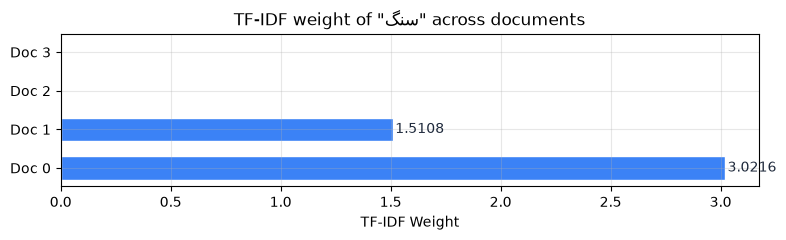


  ──────────────────────────────────────────────────
  📊 Term: 'درد'
  ├─ Appears in: 2/4 documents
  ├─ IDF weight: 1.5108
  ├─ Formula: log((1+4)/(1+2)) + 1 = 1.5108
  └─ Per-document:
     Doc 0 [سنگ کلیه درد سنگ    ]  TF=1  ×  IDF=1.5108  =  1.5108  ███████
     Doc 1 [سنگ مثانه درمان     ]  TF=0  ×  IDF=1.5108  =  0.0000  ·
     Doc 2 [دکتر خوب عالی       ]  TF=0  ×  IDF=1.5108  =  0.0000  ·
     Doc 3 [درد کمر دیسک درد    ]  TF=2  ×  IDF=1.5108  =  3.0216  ███████████████


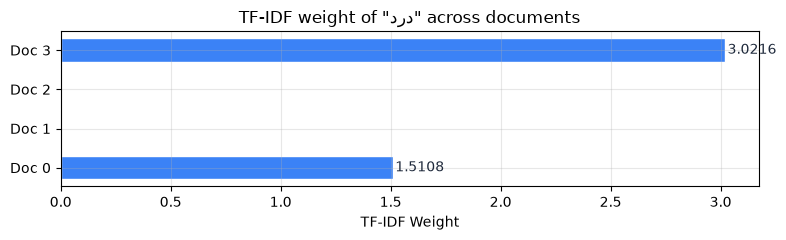


  ──────────────────────────────────────────────────
  📊 Term: 'کلیه'
  ├─ Appears in: 1/4 documents
  ├─ IDF weight: 1.9163
  ├─ Formula: log((1+4)/(1+1)) + 1 = 1.9163
  └─ Per-document:
     Doc 0 [سنگ کلیه درد سنگ    ]  TF=1  ×  IDF=1.9163  =  1.9163  █████████
     Doc 1 [سنگ مثانه درمان     ]  TF=0  ×  IDF=1.9163  =  0.0000  ·
     Doc 2 [دکتر خوب عالی       ]  TF=0  ×  IDF=1.9163  =  0.0000  ·
     Doc 3 [درد کمر دیسک درد    ]  TF=0  ×  IDF=1.9163  =  0.0000  ·


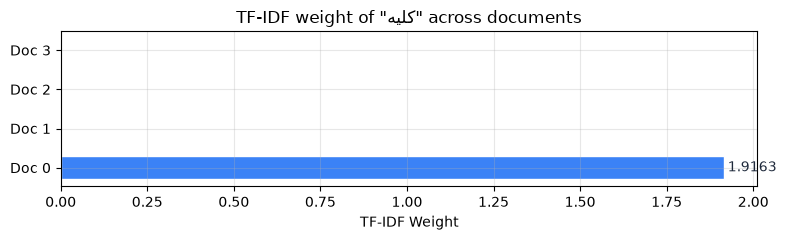

Done.


In [66]:
# --- Interactive TF-IDF Explorer ---

def show_heatmap(matrix_df, title):
    """Display a colored heatmap using pandas.style."""
    display(matrix_df.style
            .background_gradient(cmap='Blues', axis=None)
            .format('{:.4f}')
            .set_caption(title))

def explore_term_detail(term):
    """Show detailed TF/IDF/TF-IDF breakdown for one term with bar chart."""
    if term not in vocab:
        print(f"  ❌ '{term}' not found. Type 'list' to see available terms.")
        return
    
    df_count = sum(1 for doc in tokenized if term in doc)
    idf = idf_values[term]
    
    print(f"\n  {'─'*50}")
    print(f"  📊 Term: '{term}'")
    print(f"  ├─ Appears in: {df_count}/{len(corpus)} documents")
    print(f"  ├─ IDF weight: {idf:.4f}")
    print(f"  ├─ Formula: log((1+{len(corpus)})/(1+{df_count})) + 1 = {idf:.4f}")
    print(f"  └─ Per-document:")
    
    tfidf_vals = []
    for i, doc in enumerate(tokenized):
        tf = Counter(doc).get(term, 0)
        w = round(tf * idf, 4)
        tfidf_vals.append(w)
        bar = '█' * max(1, int(w * 5)) if w > 0 else '·'
        print(f"     Doc {i} [{corpus[i]:<20}]  TF={tf}  ×  IDF={idf:.4f}  =  {w:.4f}  {bar}")
    
    # Bar chart
    fig, ax = plt.subplots(figsize=(8, 2.5))
    colors = ['#3b82f6' if v > 0 else '#e2e8f0' for v in tfidf_vals]
    bars = ax.barh([f'Doc {i}' for i in range(len(corpus))], tfidf_vals, color=colors, edgecolor='white', height=0.6)
    ax.set_xlabel('TF-IDF Weight')
    ax.set_title(f'TF-IDF weight of "{term}" across documents')
    for bar, val in zip(bars, tfidf_vals):
        if val > 0:
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}', va='center', fontsize=10, color='#1e293b')
    plt.tight_layout()
    plt.show()

# --- CLI loop ---
print('=' * 55)
print('  🔬 TF-IDF Explorer — Toy Corpus (4 documents)')
print('  Commands: type a term | "all" | "list" | "exit"')
print('=' * 55)

# Show the corpus first
for i, doc in enumerate(corpus):
    print(f'  Doc {i}: {doc}')
print()

while True:
    try:
        cmd = input('🔍 Term> ').strip()
    except (EOFError, KeyboardInterrupt):
        print('\nDone.'); break
    
    if cmd.lower() in {'exit', 'quit', 'q', ''}:
        print('Done.'); break
    elif cmd.lower() == 'list':
        print(f'  Available terms: {vocab}')
    elif cmd.lower() == 'all':
        print('\n  📋 TF Matrix:')
        show_heatmap(tf_df, 'Term Frequency (raw count)')
        print('\n  📋 TF-IDF Matrix:')
        show_heatmap(tfidf_df, 'TF × IDF')
    else:
        explore_term_detail(cmd)

## 1.5 Sublinear TF: Taming Frequency with Logarithms

There's a deeper problem with raw TF: the relationship between term frequency and relevance is **not linear**.

If "سنگ" appears **100 times** in one doctor's reviews and **10 times** in another's, is the first doctor **10× more relevant** to kidney stones? Almost certainly not. The first occurrence of a word is highly informative; subsequent occurrences provide diminishing returns.

**Sublinear TF** fixes this by applying a logarithmic compression:

$$\text{tf}_{\text{sub}}(t,d) = \begin{cases} 1 + \log(\text{tf}(t,d)) & \text{if tf} > 0 \\ 0 & \text{otherwise} \end{cases}$$

This dramatically compresses high counts:

| Raw TF | Sublinear TF | Compression Ratio |
|--------|-------------|-------------------|
| 1 | 1.00 | 1.0× |
| 10 | 3.30 | 3.3× (not 10×) |
| 100 | 5.61 | 5.6× (not 100×) |
| 1000 | 7.91 | 7.9× (not 1000×) |

This is particularly important for our use case: some doctors have hundreds of comments while others have only a handful. Without sublinear TF, prolific doctors would dominate search results regardless of relevance.

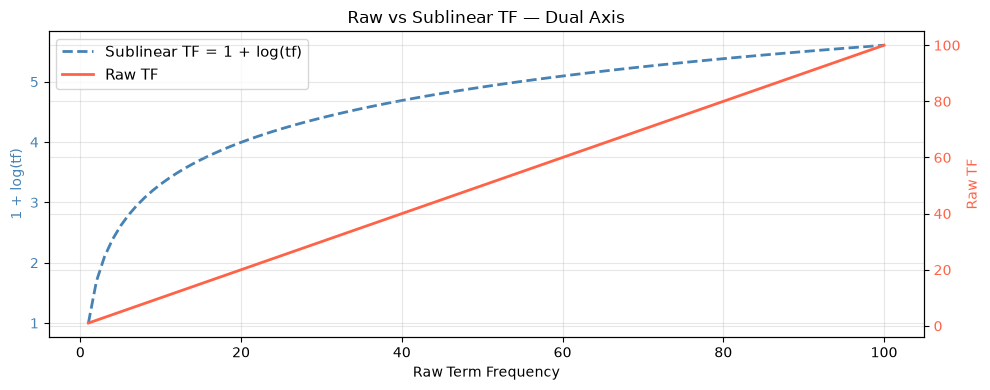

In [67]:
tf_vals = np.arange(1, 101)
raw_tf = tf_vals.astype(float)
sublinear_tf = 1 + np.log(tf_vals)
 
fig, ax1 = plt.subplots(figsize=(10, 4))
 
color_sub = "steelblue"
color_raw = "tomato"
 
ax1.plot(tf_vals, sublinear_tf, label="Sublinear TF = 1 + log(tf)", lw=2, color=color_sub, linestyle="--")
ax1.set_xlabel("Raw Term Frequency")
ax1.set_ylabel("1 + log(tf)", color=color_sub)
ax1.tick_params(axis="y", labelcolor=color_sub)
 
ax2 = ax1.twinx()
ax2.plot(tf_vals, raw_tf, label="Raw TF", lw=2, color=color_raw)
ax2.set_ylabel("Raw TF", color=color_raw)
ax2.tick_params(axis="y", labelcolor=color_raw)
 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11)
 
ax1.set_title("Raw vs Sublinear TF — Dual Axis")
plt.tight_layout()
plt.show()
 

In [68]:
2+2

4

## 1.6 L2 Normalization and Cosine Similarity

### The Length Problem

Even with sublinear TF, longer documents will tend to have larger vector magnitudes simply because they contain more words. We need to normalize vectors so that **direction** (what the document is about) matters, not **magnitude** (how long it is).

**L2 Normalization** scales each document vector to unit length:

$$\hat{v} = \frac{v}{\|v\|_2} = \frac{v}{\sqrt{\sum_i v_i^2}}$$

After this, every vector lies on the unit hypersphere ($\|\hat{v}\| = 1$).



### Cosine Similarity

With unit vectors, **cosine similarity** reduces to a simple **dot product**:

$$\text{cos\_sim}(q, d) = \frac{q \cdot d}{\|q\| \cdot \|d\|} = q \cdot d \quad \text{(when both are L2-normalized)}$$

Properties:
- **1.0** = identical direction (maximum similarity)
- **0.0** = orthogonal (no shared terms at all)
- Negative values cannot occur with TF-IDF (all components ≥ 0)

**Why cosine over Euclidean distance?** Euclidean distance is dominated by vector magnitude — a long document far from a short one simply because it has more words. Cosine similarity ignores magnitude and focuses purely on the **angle** (i.e., the *proportion* of terms), which is what we care about.

In [69]:
# 1. Convert the TF-IDF DataFrame into a raw numeric array (matrix)
# 2. Initialize an empty list to store the normalized vectors
# 3. Loop through each document's vector (row) in the matrix
# 4. Calculate the sum of squares for all values in the current row
# 5. Calculate the square root of that sum to get the L2 Norm (length of the vector)
# 6. Check if the norm is zero (to prevent division by zero errors)
# 7. If the norm is zero, keep the row as all zeros
# 8. Otherwise, create a new list for the normalized row
# 9. Loop through each individual TF-IDF score in the row
# 10. Divide each score by the row's L2 Norm to normalize it
# 11. Append the normalized row to our final matrix
# 12. Convert the final matrix back into a clean Pandas DataFrame

tfidf_arr = tfidf_df.values.astype(float)
tfidf_normed_list = []

for row in tfidf_arr:
    # Calculate sum of squares: x^2 + y^2 + z^2 ...
    sum_of_squares = 0
    for value in row:
        sum_of_squares += value ** 2
    
    # Calculate the L2 Norm (Length)
    l2_norm = np.sqrt(sum_of_squares)
    
    # Handle the division and normalization
    normed_row = []
    if l2_norm == 0:
        normed_row = [0.0] * len(row)
    else:
        for value in row:
            normed_row.append(value / l2_norm)
            
    tfidf_normed_list.append(normed_row)

# Re-wrap it into a DataFrame for a nice display
tfidf_normed = pd.DataFrame(
    tfidf_normed_list, 
    columns=vocab, 
    index=tfidf_df.index
)

tfidf_normed = tfidf_normed.round(4)
tfidf_normed

,خوب,درد,درمان,دکتر,دیسک,سنگ,عالی,مثانه,کلیه,کمر
Doc 0,0.0000,0.3890,0.0000,0.0000,0.0000,0.7780,0.0000,0.0000,0.4934,0.0000
Doc 1,0.0000,0.0000,0.6176,0.0000,0.0000,0.4869,0.0000,0.6176,0.0000,0.0000
Doc 2,0.5774,0.0000,0.0000,0.5774,0.0000,0.0000,0.5774,0.0000,0.0000,0.0000
Doc 3,0.0000,0.7444,0.0000,0.0000,0.4721,0.0000,0.0000,0.0000,0.0000,0.4721


In [70]:
# L2-normalize the TF-IDF matrix
# tfidf_arr = tfidf_df.values.astype(float)
# l2 = np.sqrt(np.sum(tfidf_arr ** 2, axis=1, keepdims=True))
# l2[l2 == 0] = 1.0
# tfidf_normed = tfidf_arr / l2

In [71]:


# Build and normalize a query vector for "سنگ کلیه"
query = "سنگ کلیه"
q_c = Counter(query.split())
q_vec = np.array([q_c.get(t, 0) * idf_values[t] for t in vocab])
q_vec = q_vec / (np.linalg.norm(q_vec) or 1.0)
q_vec = q_vec.round(4)
# Compute cosine similarity (= dot product since both are normalized)
print(f"Query: '{query}'\n")
print(f"Query ٰVector : '{q_vec}'\n")

Query: 'سنگ کلیه'

Query ٰVector : '[0.     0.     0.     0.     0.     0.6191 0.     0.     0.7853 0.    ]'



In [72]:
tfidf_normed.iloc[0].tolist()


[0.0, 0.389, 0.0, 0.0, 0.0, 0.778, 0.0, 0.0, 0.4934, 0.0]

In [73]:



similarities = []
for i in range(len(corpus)):
    sim = np.dot(q_vec, tfidf_normed.iloc[i])
    similarities.append(sim)
    tag = "✅ Relevant" if sim > 0.3 else ("⚠️ Partial" if sim > 0.1 else "❌ Irrelevant")
    print(f"  Doc {i}: {corpus[i]:<25} sim={sim:.4f}  {tag}")

ranked = sorted(enumerate(similarities), key=lambda x: -x[1])
print(f"\n→ Ranking: {' > '.join(f'Doc {i} ({s:.3f})' for i, s in ranked)}")

  Doc 0: سنگ کلیه درد سنگ          sim=0.8691  ✅ Relevant
  Doc 1: سنگ مثانه درمان           sim=0.3014  ✅ Relevant
  Doc 2: دکتر خوب عالی             sim=0.0000  ❌ Irrelevant
  Doc 3: درد کمر دیسک درد          sim=0.0000  ❌ Irrelevant

→ Ranking: Doc 0 (0.869) > Doc 1 (0.301) > Doc 2 (0.000) > Doc 3 (0.000)


## Vectorizer Configuration — Why Each Parameter?

| Parameter | Value | Why? |
|---|---|---|
| `tokenizer=str.split` | split on space | Text is already tokenized by preprocessing |
| `preprocessor=None` | none | Do not lowercase/strip — preprocessing already did it |
| `token_pattern=None` | disable | Required when passing a custom tokenizer |
| `min_df=2` | 2 | Ignore terms in only 1 doctor → typos, very rare names |
| `max_df=0.95` | 95% | Ignore terms in >95% of doctors → too common to be useful |
| `ngram_range=(1, 2)` | unigram + bigram | Capture phrases like `سنگ کلیه` as single features |
| `max_features=60000` | 60K | Keep memory bounded; covers vast majority of useful terms |
| `sublinear_tf=True` | True | `1 + log(tf)` — compress huge counts (Part 1.7) |
| `norm='l2'` | L2 | Fair comparison regardless of doc length (Part 1.4) |

## 1.7 Verification: Our Math = sklearn

Let's confirm that sklearn's `TfidfVectorizer` produces the **exact same results** as our manual computation. This builds confidence that we understand the algorithm correctly before applying it to real data.

In [74]:


vec_demo = TfidfVectorizer(
    tokenizer=str.split,    # text is already tokenized
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
    sublinear_tf=True,      # 1 + log(tf)
    norm='l2',              # L2 normalize each row
)
query = "سنگ کلیه"

X_demo = vec_demo.fit_transform(corpus)
sims_sk = cosine_similarity(vec_demo.transform([query]), X_demo).ravel()

print(f"Query: '{query}'\n")
for i, (m, s) in enumerate(zip(similarities, sims_sk)):
    print(f"  Doc {i}: manual={m:.4f}  sklearn={s:.4f}  {'✓ Match' if abs(m-s)<0.01 else '✗ Mismatch'}")

Query: 'سنگ کلیه'

  Doc 0: manual=0.8691  sklearn=0.8736  ✓ Match
  Doc 1: manual=0.3014  sklearn=0.3015  ✓ Match
  Doc 2: manual=0.0000  sklearn=0.0000  ✓ Match
  Doc 3: manual=0.0000  sklearn=0.0000  ✓ Match


## 1.8 N-grams: Capturing Multi-Word Medical Phrases

With unigrams only, the query "سنگ کلیه" (kidney stone) is decomposed into two independent terms: "سنگ" and "کلیه". This means a document about "سنگ صفرا" (gallstone) would score similarly to one about "سنگ کلیه", because both contain "سنگ".

By adding **bigrams** (`ngram_range=(1,2)`), we create features like:
- Unigrams: `سنگ`, `کلیه`, `صفرا`, ...
- Bigrams: `سنگ کلیه`, `سنگ صفرا`, ...

Now "سنگ کلیه" is a **single feature** with its own IDF weight, and a document about gallstones won't match it.

This is particularly important in medical text where **multi-word terms** carry specific meanings: "سنگ کلیه" ≠ "سنگ مثانه" ≠ "سنگ صفرا".

In [79]:
c_bi = ["سنگ کلیه درد شدید", "سنگ صفرا درمان", "کلیه پیوند عمل"]
v1 = TfidfVectorizer(tokenizer=str.split, preprocessor=None, token_pattern=None, ngram_range=(1,1), norm="l2", sublinear_tf=True)
v2 = TfidfVectorizer(tokenizer=str.split, preprocessor=None, token_pattern=None, ngram_range=(1,2), norm="l2", sublinear_tf=True)


In [80]:
v2

,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",<method 'spli...'str' objects>
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",None
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'


In [29]:
print(f"\n→ Bigram features created: {sorted(v2.get_feature_names_out())}")
print(f"\n→ Unigram features created: {sorted(v1.get_feature_names_out())}")

NotFittedError: Vocabulary not fitted or provided

In [35]:
len(['درد', 'درد شدید', 'درمان', 'سنگ', 'سنگ صفرا', 'سنگ کلیه', 'شدید', 'صفرا', 'صفرا درمان', 'عمل', 'پیوند', 'پیوند عمل', 'کلیه', 'کلیه درد', 'کلیه پیوند'])

15

In [36]:
len( ['درد', 'درمان', 'سنگ', 'شدید', 'صفرا', 'عمل', 'پیوند', 'کلیه'])

8

In [50]:

s1 = cosine_similarity(v1.fit_transform(c_bi), v1.transform(["سنگ کلیه"])).ravel()
s2 = cosine_similarity(v2.fit_transform(c_bi), v2.transform(["سنگ کلیه"])).ravel()

print(f"Query: 'سنگ کلیه'\n")
for i, d in enumerate(c_bi):
    delta = "↑" if s2[i] > s1[i] + 0.01 else ("↓" if s2[i] < s1[i] - 0.01 else "=")
    print(f"  {d:<25}  Unigram={s1[i]:.4f}  Bigram={s2[i]:.4f}  {delta}")
print(f"\n→ Bigram features created: {sorted(v2.get_feature_names_out())}")

Query: 'سنگ کلیه'

  سنگ کلیه درد شدید          Unigram=0.6053  Bigram=0.5919  ↓
  سنگ صفرا درمان             Unigram=0.3349  Bigram=0.1841  ↓
  کلیه پیوند عمل             Unigram=0.3349  Bigram=0.1841  ↓

→ Bigram features created: ['درد', 'درد شدید', 'درمان', 'سنگ', 'سنگ صفرا', 'سنگ کلیه', 'شدید', 'صفرا', 'صفرا درمان', 'عمل', 'پیوند', 'پیوند عمل', 'کلیه', 'کلیه درد', 'کلیه پیوند']
